# **Sentiment Analysis using RNN (IMDB Movie Reviews)**

# Libraries:

In [1]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix


# Load IMDB Dataset

In [2]:
# 10,000 most common words only
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Train Data:", len(X_train))
print("Test Data:", len(X_test))
print("Sample Label:", y_train[0], "-> 1=Positive, 0=Negative")
print("Sample Review Length:", len(X_train[0]))
print("Sample Review (numbers):", X_train[0][:10])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train Data: 25000
Test Data: 25000
Sample Label: 1 -> 1=Positive, 0=Negative
Sample Review Length: 218
Sample Review (numbers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]


# Sequences Test & Train:

In [3]:
# Pad sequences - all reviews same length
max_length = 200

X_train_pad = pad_sequences(X_train, maxlen=max_length)
X_test_pad = pad_sequences(X_test, maxlen=max_length)

print("X_train shape:", X_train_pad.shape)
print("X_test shape:", X_test_pad.shape)

# Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("\nClass Distribution:")
for u, c in zip(unique, counts):
    label = "Positive" if u == 1 else "Negative"
    print(f"  {label}: {c}")

X_train shape: (25000, 200)
X_test shape: (25000, 200)

Class Distribution:
  Negative: 12500
  Positive: 12500


# Build RNN Model:

In [5]:
# Build RNN Model (Fixed)
model = Sequential()

# Embedding Layer
model.add(Embedding(vocab_size, 128))

# First RNN Layer
model.add(SimpleRNN(64, return_sequences=True))
model.add(Dropout(0.3))

# Second RNN Layer
model.add(SimpleRNN(32, return_sequences=False))
model.add(Dropout(0.3))

# Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Build model with input shape
model.build(input_shape=(None, max_length))

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 200, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297,633 (4.95 MB)

 Trainable params: 1,297,633 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

None


# Train RNN Model:


In [6]:
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

print("Training Complete!")

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 176ms/step - accuracy: 0.6166 - loss: 0.6432 - val_accuracy: 0.6635 - val_loss: 0.6242
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 178ms/step - accuracy: 0.7980 - loss: 0.4588 - val_accuracy: 0.6920 - val_loss: 0.5782
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 176ms/step - accuracy: 0.7811 - loss: 0.4575 - val_accuracy: 0.7367 - val_loss: 0.5286
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 69s 175ms/step - accuracy: 0.8924 - loss: 0.2797 - val_accuracy: 0.8034 - val_loss: 0.4721
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 195ms/step - accuracy: 0.9550 - loss: 0.1321 - val_accuracy: 0.8138 - val_loss: 0.5670
Training Complete!


# Evaluate Model:


In [7]:
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 81.38%
Test Loss: 0.5670


# Accuracy & Loss Polt Visualization:

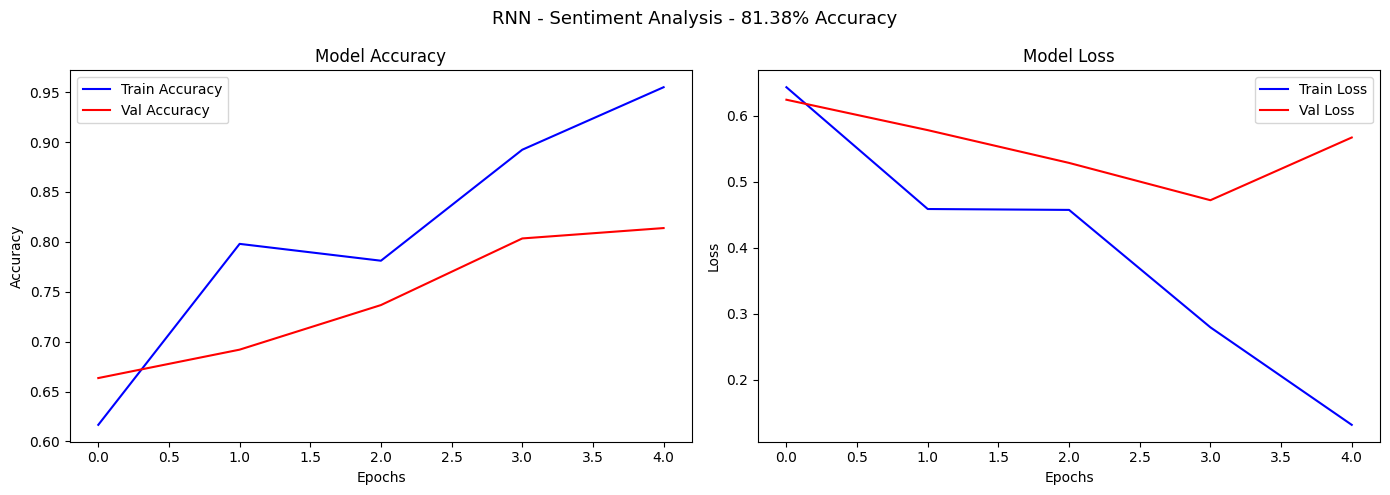

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Accuracy Plot
axes[0].plot(history.history['accuracy'], color='blue', label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], color='red', label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# 2. Loss Plot
axes[1].plot(history.history['loss'], color='blue', label='Train Loss')
axes[1].plot(history.history['val_loss'], color='red', label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('RNN - Sentiment Analysis - 81.38% Accuracy', fontsize=13)
plt.tight_layout()
plt.show()

# Confusion Matrix Visualization:

782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step


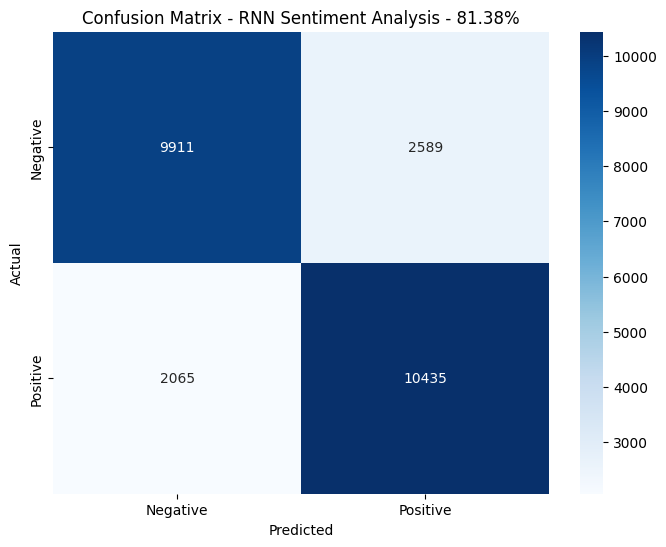

              precision    recall  f1-score   support

    Negative       0.83      0.79      0.81     12500
    Positive       0.80      0.83      0.82     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



In [9]:
# Predictions
y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - RNN Sentiment Analysis - 81.38%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Positive']))

# Four Type Visualization:

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step


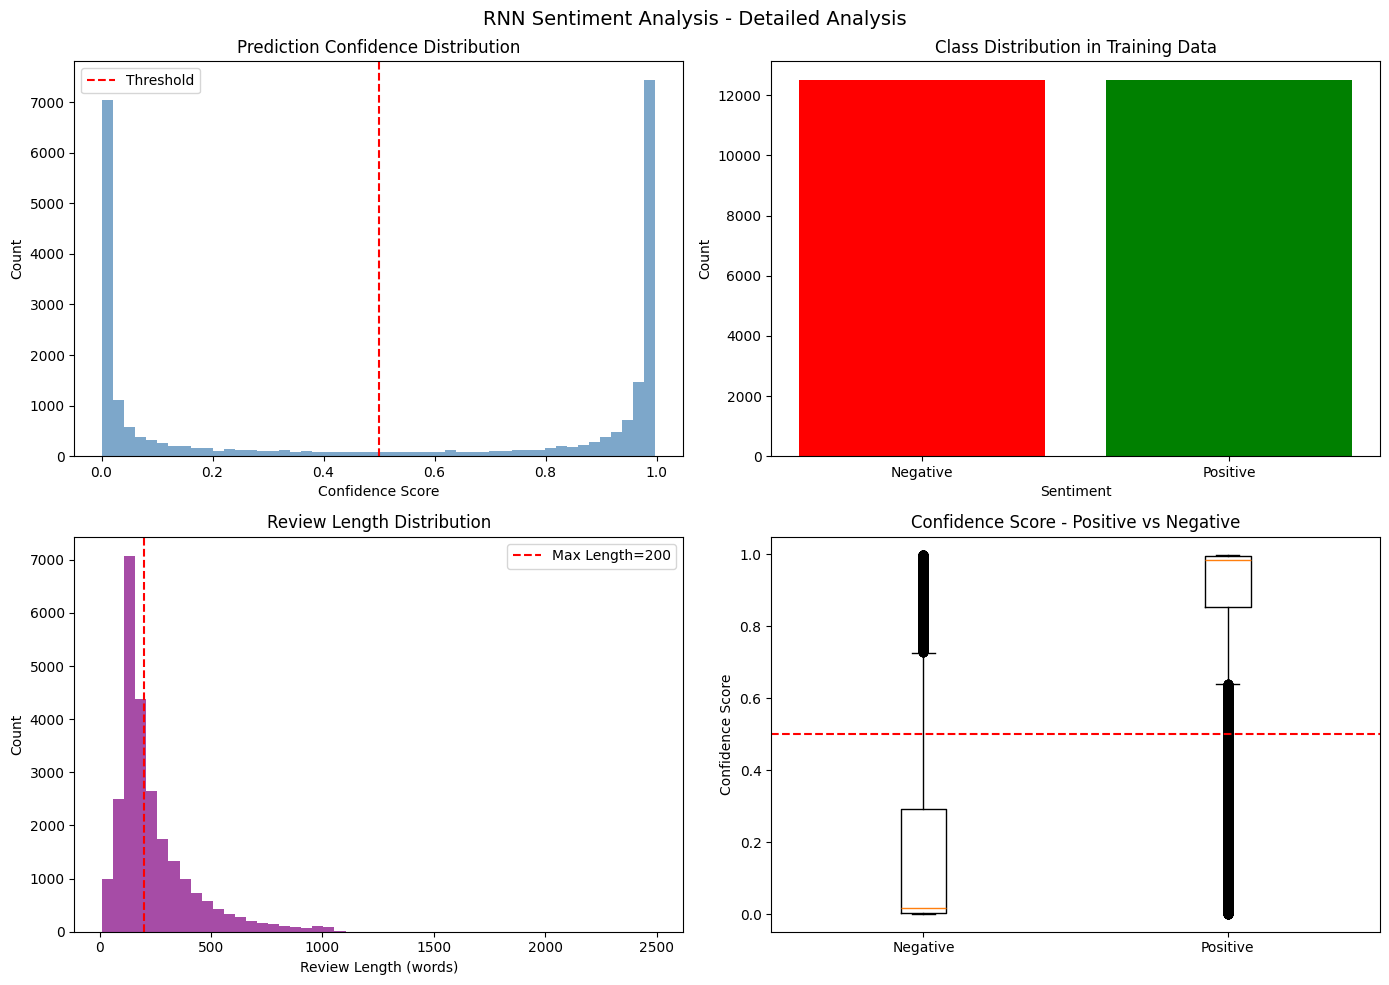

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Prediction Confidence Distribution
y_pred_prob = model.predict(X_test_pad)
axes[0,0].hist(y_pred_prob, bins=50, color='steelblue', alpha=0.7)
axes[0,0].set_title('Prediction Confidence Distribution')
axes[0,0].set_xlabel('Confidence Score')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(x=0.5, color='red', linestyle='--', label='Threshold')
axes[0,0].legend()

# 2. Class Distribution - Bar Plot
class_counts = np.bincount(y_train)
axes[0,1].bar(['Negative', 'Positive'], class_counts, color=['red', 'green'])
axes[0,1].set_title('Class Distribution in Training Data')
axes[0,1].set_xlabel('Sentiment')
axes[0,1].set_ylabel('Count')

# 3. Review Length Distribution
review_lengths = [len(x) for x in X_train]
axes[1,0].hist(review_lengths, bins=50, color='purple', alpha=0.7)
axes[1,0].set_title('Review Length Distribution')
axes[1,0].set_xlabel('Review Length (words)')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(x=200, color='red', linestyle='--', label='Max Length=200')
axes[1,0].legend()

# 4. Confidence Box Plot - Positive vs Negative
pos_conf = y_pred_prob[y_test == 1].flatten()
neg_conf = y_pred_prob[y_test == 0].flatten()
axes[1,1].boxplot([neg_conf, pos_conf], tick_labels=['Negative', 'Positive'])
axes[1,1].set_title('Confidence Score - Positive vs Negative')
axes[1,1].set_ylabel('Confidence Score')
axes[1,1].axhline(y=0.5, color='red', linestyle='--')

plt.suptitle('RNN Sentiment Analysis - Detailed Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# Six Type Visualization:

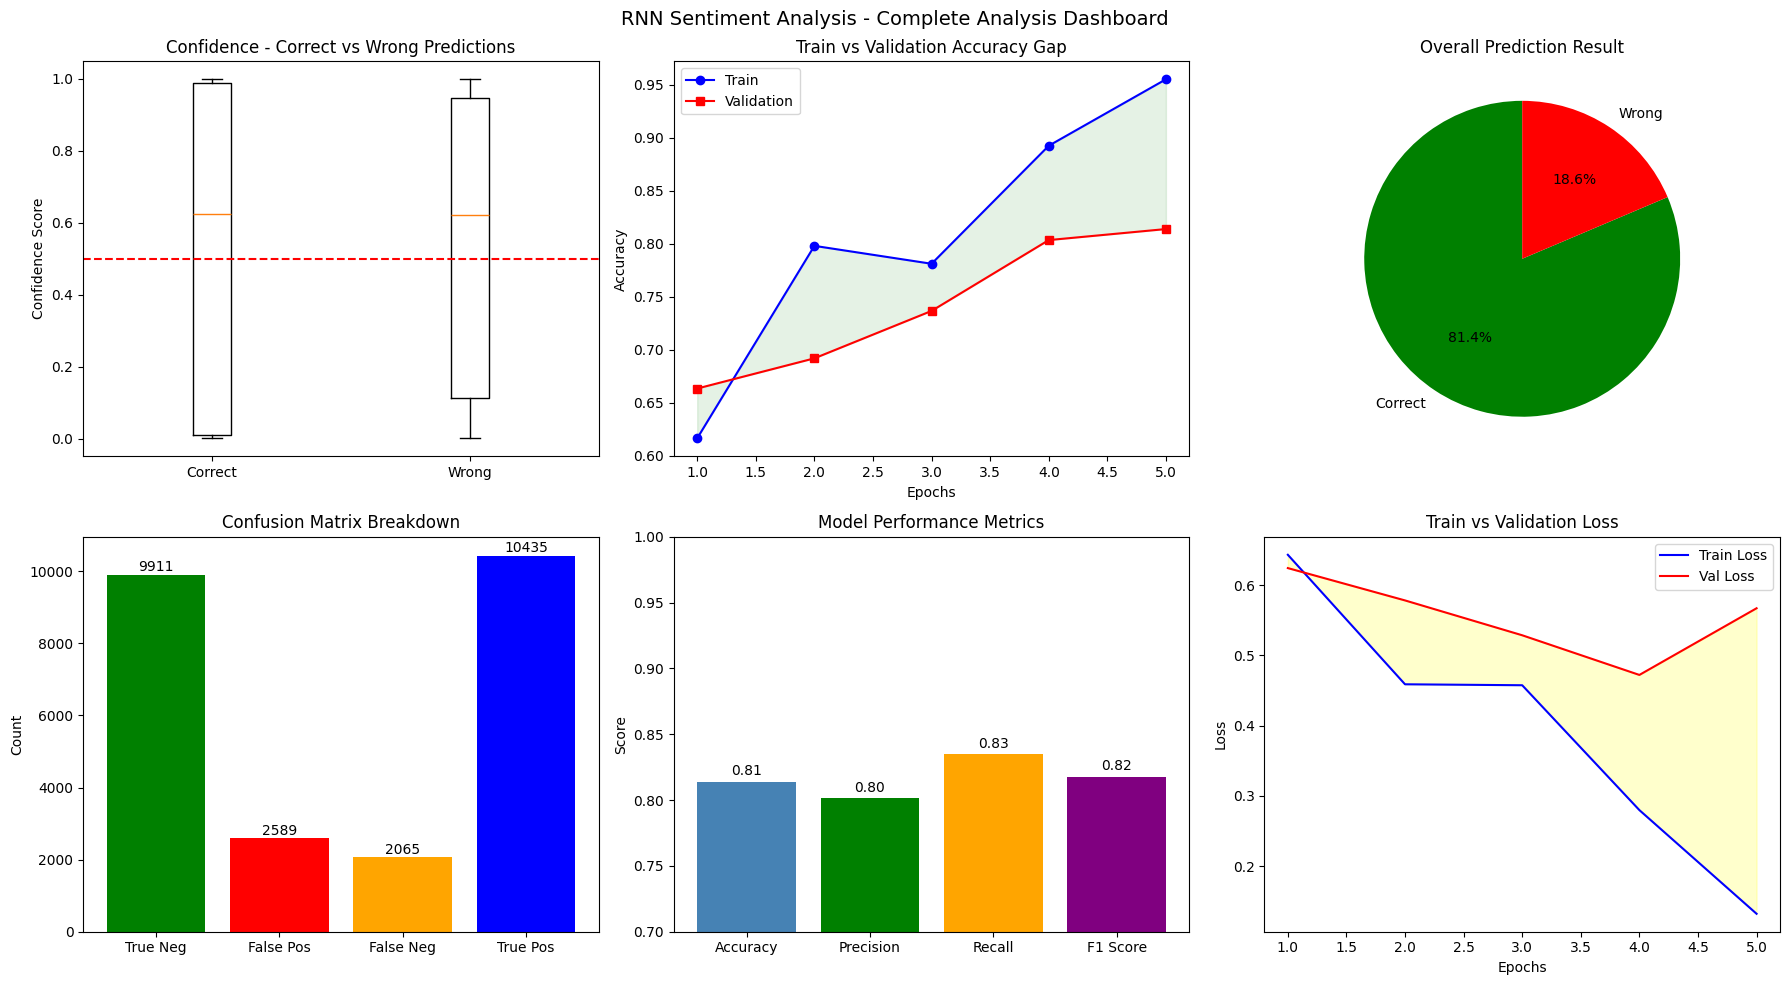

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Correct vs Wrong Confidence - Box Plot
correct_conf = y_pred_prob[y_test == y_pred.flatten()].flatten()
wrong_conf = y_pred_prob[y_test != y_pred.flatten()].flatten()
axes[0,0].boxplot([correct_conf, wrong_conf], tick_labels=['Correct', 'Wrong'])
axes[0,0].set_title('Confidence - Correct vs Wrong Predictions')
axes[0,0].set_ylabel('Confidence Score')
axes[0,0].axhline(y=0.5, color='red', linestyle='--')

# 2. Epoch vs Accuracy - Line Plot
epochs = range(1, len(history.history['accuracy']) + 1)
axes[0,1].plot(epochs, history.history['accuracy'], 'bo-', label='Train')
axes[0,1].plot(epochs, history.history['val_accuracy'], 'rs-', label='Validation')
axes[0,1].fill_between(epochs,
                        history.history['accuracy'],
                        history.history['val_accuracy'],
                        alpha=0.1, color='green')
axes[0,1].set_title('Train vs Validation Accuracy Gap')
axes[0,1].set_xlabel('Epochs')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# 3. Prediction Distribution - Pie Chart
correct = int((y_test == y_pred.flatten()).sum())
wrong = int((y_test != y_pred.flatten()).sum())
axes[0,2].pie([correct, wrong],
              labels=['Correct', 'Wrong'],
              colors=['green', 'red'],
              autopct='%1.1f%%',
              startangle=90)
axes[0,2].set_title('Overall Prediction Result')

# 4. True Positive, True Negative, FP, FN - Bar Plot
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
bars = axes[1,0].bar(['True Neg', 'False Pos', 'False Neg', 'True Pos'],
                      [tn, fp, fn, tp],
                      color=['green', 'red', 'orange', 'blue'])
axes[1,0].set_title('Confusion Matrix Breakdown')
axes[1,0].set_ylabel('Count')
for bar, val in zip(bars, [tn, fp, fn, tp]):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 100,
                   str(val), ha='center', fontsize=10)

# 5. Precision, Recall, F1 - Bar Plot
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = test_accuracy

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
colors = ['steelblue', 'green', 'orange', 'purple']
bars2 = axes[1,1].bar(metrics, values, color=colors)
axes[1,1].set_title('Model Performance Metrics')
axes[1,1].set_ylabel('Score')
axes[1,1].set_ylim([0.7, 1.0])
for bar, val in zip(bars2, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.005,
                   f'{val:.2f}', ha='center', fontsize=10)

# 6. Loss Curve with Fill
axes[1,2].plot(epochs, history.history['loss'], 'b-', label='Train Loss')
axes[1,2].plot(epochs, history.history['val_loss'], 'r-', label='Val Loss')
axes[1,2].fill_between(epochs,
                        history.history['loss'],
                        history.history['val_loss'],
                        alpha=0.2, color='yellow')
axes[1,2].set_title('Train vs Validation Loss')
axes[1,2].set_xlabel('Epochs')
axes[1,2].set_ylabel('Loss')
axes[1,2].legend()

plt.suptitle('RNN Sentiment Analysis - Complete Analysis Dashboard', fontsize=14)
plt.tight_layout()
plt.show()